# TC5061 - Baseline de Machine Learning con Titanic

**Estudiante:** Juan Pablo Islas Guzman  
**Modalidad:** Individual  
**Objetivo:** recorrer un flujo reproducible de exploracion, limpieza, modelado, evaluacion y registro con MLflow.

En este notebook se construye un modelo base para predecir si una persona sobrevivio al hundimiento del Titanic. El objetivo no es obtener el mejor modelo, sino documentar un punto de partida medible y reproducible.

## 1. Configuracion y carga del dataset

El dataset Titanic de Seaborn contiene informacion demografica y del viaje de pasajeros. La variable `survived` es el objetivo binario: `1` significa que la persona sobrevivio y `0` que no sobrevivio.

In [1]:
import os
import warnings
from pathlib import Path

import mlflow
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from mlflow.models import infer_signature
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
RANDOM_STATE = 42
ARTIFACT_DIR = Path('artifacts')
ARTIFACT_DIR.mkdir(exist_ok=True)

2026/10/04 20:11:01 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at /opt/anaconda3/lib/python3.13/site-packages/mlflow/assistant/skills/instrumenting-with-mlflow-tracing/SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


In [2]:
df = sns.load_dataset('titanic')
print(f'Registros: {df.shape[0]:,}')
print(f'Variables: {df.shape[1]}')
display(df.head())
display(df.dtypes.to_frame('tipo'))

Registros: 891
Variables: 15


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


,tipo
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


### Descripcion de las variables

Las variables principales son `survived` (objetivo), `pclass` (clase del boleto), `sex`, `age`, `sibsp`, `parch`, `fare`, `embarked`, `class`, `who`, `adult_male`, `deck`, `embark_town`, `alive` y `alone`. Para evitar fuga de informacion, el modelo usara solo variables disponibles antes de conocer el resultado y no usara `alive`, que es equivalente al objetivo.

## 2. Analisis exploratorio de datos (EDA)

In [3]:
display(df.describe(include='all').T)
print('Duplicados:', df.duplicated().sum())
display(df.isna().sum().sort_values(ascending=False).to_frame('faltantes'))

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Duplicados: 107


,faltantes
deck,688
age,177
embarked,2
embark_town,2
survived,0
pclass,0
sex,0
sibsp,0
parch,0
fare,0


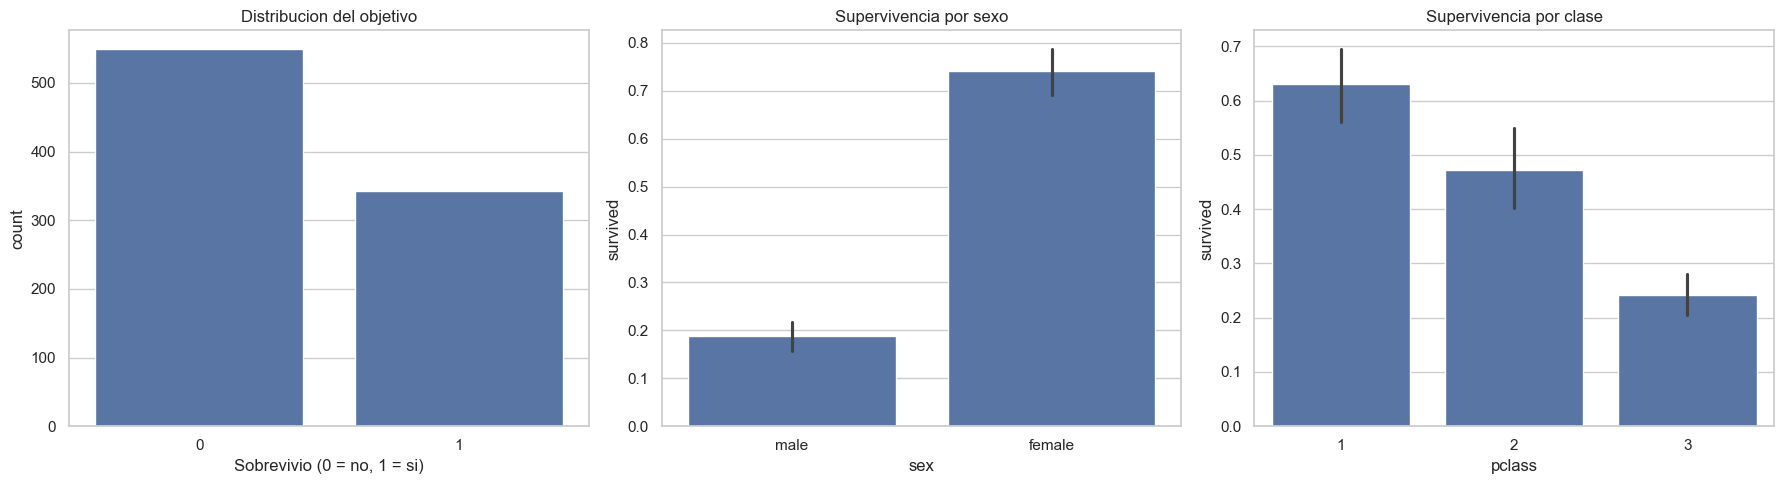

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(data=df, x='survived', ax=axes[0])
axes[0].set_title('Distribucion del objetivo')
axes[0].set_xlabel('Sobrevivio (0 = no, 1 = si)')
sns.barplot(data=df, x='sex', y='survived', ax=axes[1])
axes[1].set_title('Supervivencia por sexo')
sns.barplot(data=df, x='pclass', y='survived', ax=axes[2])
axes[2].set_title('Supervivencia por clase')
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'eda_supervivencia.png', dpi=150)
plt.show()

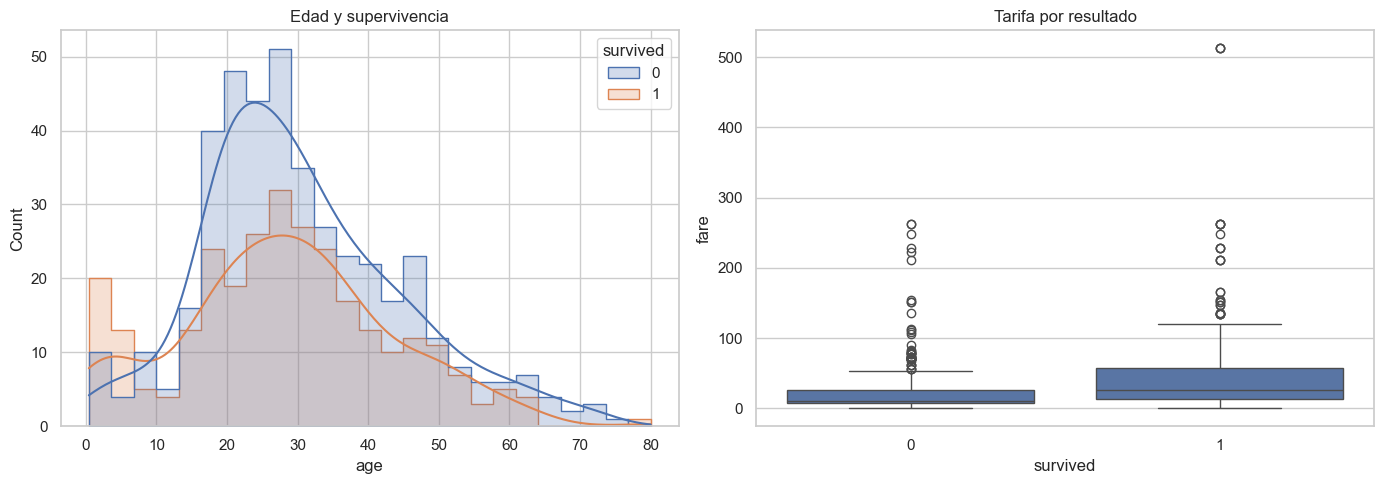

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='age', hue='survived', kde=True, bins=25, element='step', ax=axes[0])
axes[0].set_title('Edad y supervivencia')
sns.boxplot(data=df, x='survived', y='fare', ax=axes[1])
axes[1].set_title('Tarifa por resultado')
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'eda_distribuciones.png', dpi=150)
plt.show()

## 3. Limpieza y preparacion

Decisiones de calidad de datos:

- Se eliminan duplicados exactos para evitar que una misma observacion tenga peso adicional.
- `age` y `fare` son numericas; sus faltantes se imputan con la mediana calculada solo en entrenamiento.
- `embarked` y `embark_town` son categoricas; sus faltantes se imputan con la moda.
- No se eliminan outliers de `fare` automaticamente: una tarifa alta puede representar una clase real del viaje. Se identifican con IQR y se conservan para no eliminar casos validos.
- El preprocesamiento se implementa dentro de un `Pipeline` para evitar fuga de informacion entre entrenamiento y prueba. El escalamiento estandariza las variables numericas, pero no elimina la influencia de los outliers.

In [6]:
df_clean = df.drop_duplicates().copy()
target = 'survived'
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone']
model_df = df_clean[features + [target]].copy()

X = model_df[features]
y = model_df[target].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

numeric_features = ['pclass', 'age', 'sibsp', 'parch', 'fare']
categorical_features = ['sex', 'embarked', 'alone']

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_features),
    ('categorical', categorical_pipeline, categorical_features)
])

print('Registros antes de limpiar:', len(df))
print('Registros despues de eliminar duplicados:', len(df_clean))
print('Entrenamiento:', X_train.shape[0], '| Prueba:', X_test.shape[0])

Registros antes de limpiar: 891
Registros despues de eliminar duplicados: 784
Entrenamiento: 627 | Prueba: 157


In [7]:
# Verificamos tipos, faltantes y posibles outliers antes de entrenar.
print('Tipos originales:')
display(df_clean[features + [target]].dtypes.to_frame('tipo'))

# El dataset ya contiene los tipos esperados; convertimos el objetivo a entero por seguridad.
assert pd.api.types.is_numeric_dtype(df_clean[target])
df_clean[target] = df_clean[target].astype(int)

# Usamos IQR para identificar valores extremos, sin eliminarlos automaticamente.
outlier_report = {}
for column in ['age', 'fare']:
    first_quartile = df_clean[column].quantile(0.25)
    third_quartile = df_clean[column].quantile(0.75)
    iqr = third_quartile - first_quartile
    lower_bound = first_quartile - 1.5 * iqr
    upper_bound = third_quartile + 1.5 * iqr
    outlier_report[column] = int(((df_clean[column] < lower_bound) | (df_clean[column] > upper_bound)).sum())

display(pd.Series(outlier_report, name='outliers detectados').to_frame())
print('Decision: se conservan los outliers porque pueden representar pasajeros reales; el modelo los recibe escalados.')

Tipos originales:


,tipo
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
alone,bool
survived,int64


,outliers detectados
age,7
fare,102


Decision: se conservan los outliers porque pueden representar pasajeros reales; el modelo los recibe escalados.


## 4. Entrenamiento del modelo baseline

Se selecciona regresion logistica porque es un modelo sencillo, interpretable y apropiado para una variable objetivo binaria. El valor de `C=1.0` se mantiene como configuracion base, sin busqueda de hiperparametros.

In [8]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE))
])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Modelo baseline entrenado correctamente.')

Modelo baseline entrenado correctamente.


## 5. Evaluacion e interpretacion

Se reportan accuracy, precision, recall y F1. En este contexto, accuracy resume el porcentaje de predicciones correctas; precision mide cuantas personas predichas como sobrevivientes realmente sobrevivieron; recall mide cuantas de las personas sobrevivientes fueron identificadas. F1 combina precision y recall.

,accuracy,precision,recall,f1
baseline,0.828,0.7794,0.8154,0.797


               precision    recall  f1-score   support

No sobrevivio       0.87      0.84      0.85        92
   Sobrevivio       0.78      0.82      0.80        65

     accuracy                           0.83       157
    macro avg       0.82      0.83      0.82       157
 weighted avg       0.83      0.83      0.83       157



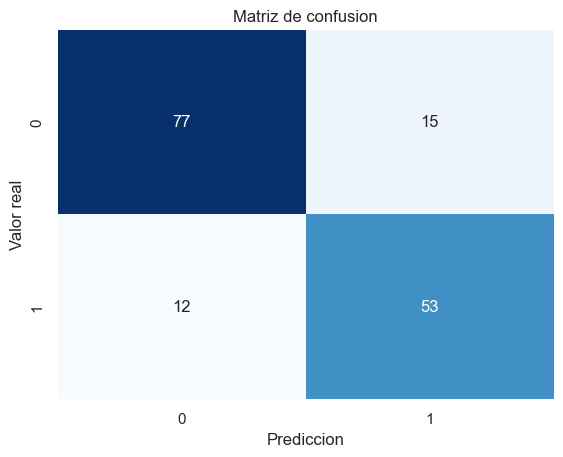

In [9]:
metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred)
}
display(pd.DataFrame([metrics], index=['baseline']).round(4))
print(classification_report(y_test, y_pred, target_names=['No sobrevivio', 'Sobrevivio']))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Prediccion')
plt.ylabel('Valor real')
plt.title('Matriz de confusion')
plt.savefig(ARTIFACT_DIR / 'matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretacion

El resultado obtenido representa el punto de partida del proyecto, no una solucion definitiva. Un accuracy cercano a la proporcion de predicciones correctas indica que el modelo captura parte de la relacion entre las variables del pasajero y la supervivencia. La matriz de confusion permite observar los errores de falsos positivos y falsos negativos. Para mejorar el modelo seria necesario comparar varios algoritmos, validar con particiones cruzadas y revisar si las variables disponibles son suficientes.

## 6. Registro del experimento en MLflow

La siguiente celda registra el experimento, los parametros, las metricas y los artefactos generados. Antes de ejecutar, puede iniciarse la interfaz con `mlflow ui` desde la carpeta del proyecto y abrir `http://127.0.0.1:5000`. Despues de ejecutar la celda, toma una captura donde se vean el experimento, la corrida, parametros y metricas; esa captura debe agregarse como evidencia en la entrega.

In [10]:
mlflow.set_experiment('TC5061_Titanic_Baseline')

with mlflow.start_run(run_name='logistic_regression_baseline') as run:
    mlflow.log_param('model_type', 'LogisticRegression')
    mlflow.log_param('C', 1.0)
    mlflow.log_param('test_size', 0.20)
    mlflow.log_param('random_state', RANDOM_STATE)
    mlflow.log_param('feature_count', len(features))
    mlflow.log_metrics(metrics)
    mlflow.log_artifacts(str(ARTIFACT_DIR))
    signature = infer_signature(X_train, model.predict(X_train))
    # Pickle evita la validacion restrictiva de tipos de skops en este baseline.
    mlflow.sklearn.log_model(
        model,
        'model',
        signature=signature,
        input_example=X_train.head(3),
        serialization_format='pickle'
    )
    run_id = run.info.run_id

print('Experimento:', 'TC5061_Titanic_Baseline')
print('Run ID:', run_id)
print('Metricas registradas:', metrics)

2026/10/04 20:11:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/10/04 20:11:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Experimento: TC5061_Titanic_Baseline
Run ID: 11260aa2365f445cb4ad16410ae1d7b8
Metricas registradas: {'accuracy': 0.8280254777070064, 'precision': 0.7794117647058824, 'recall': 0.8153846153846154, 'f1': 0.7969924812030075}


## 7. Reflexion final: mejoras con MLOps

Este ejercicio muestra que un modelo de Machine Learning no debe evaluarse solamente por obtener una metrica. En un escenario profesional, aplicaria practicas de MLOps para hacer que el flujo fuera repetible, auditable y facil de mantener. Primero, versionaria el dataset, el notebook y el codigo con Git, y registraria la fecha, la fuente de los datos y las transformaciones utilizadas. Tambien automatizaria pruebas de calidad para detectar cambios en tipos, valores faltantes, duplicados y distribuciones antes de entrenar. En MLflow compararia varias corridas, modelos y versiones de parametros, en lugar de conservar un unico resultado. Para una siguiente iteracion usaria validacion cruzada, busqueda controlada de hiperparametros y un conjunto de validacion separado. Ademas, revisaria sesgos por sexo, clase y edad, porque una buena metrica promedio no garantiza un comportamiento justo para todos los grupos. Finalmente, empaquetaria el modelo, documentaria su contrato de entrada y configuraria monitoreo de rendimiento y deriva de datos. Estas practicas conectan directamente con mi area profesional porque permiten entregar soluciones confiables, explicar decisiones ante otras personas y detectar rapidamente cuando un modelo deja de representar la realidad.

## Checklist de entrega

- [x] Carga y descripcion del dataset.
- [x] Estadisticas descriptivas y visualizaciones EDA.
- [x] Limpieza documentada: duplicados, faltantes, outliers y tipos.
- [x] Modelo baseline con division entrenamiento/prueba.
- [x] Metricas coherentes e interpretacion.
- [x] Registro de parametros, metricas, artefactos y modelo en MLflow.
- [x] Captura de la interfaz de MLflow incrustada en el notebook.
- [x] Reflexion final con mas de 150 palabras.

## Evidencia de MLflow

La siguiente captura muestra la interfaz de MLflow con la corrida `logistic_regression_baseline` finalizada y sus resultados registrados.

![Evidencia del experimento en MLflow](mlflow_evidence.png)

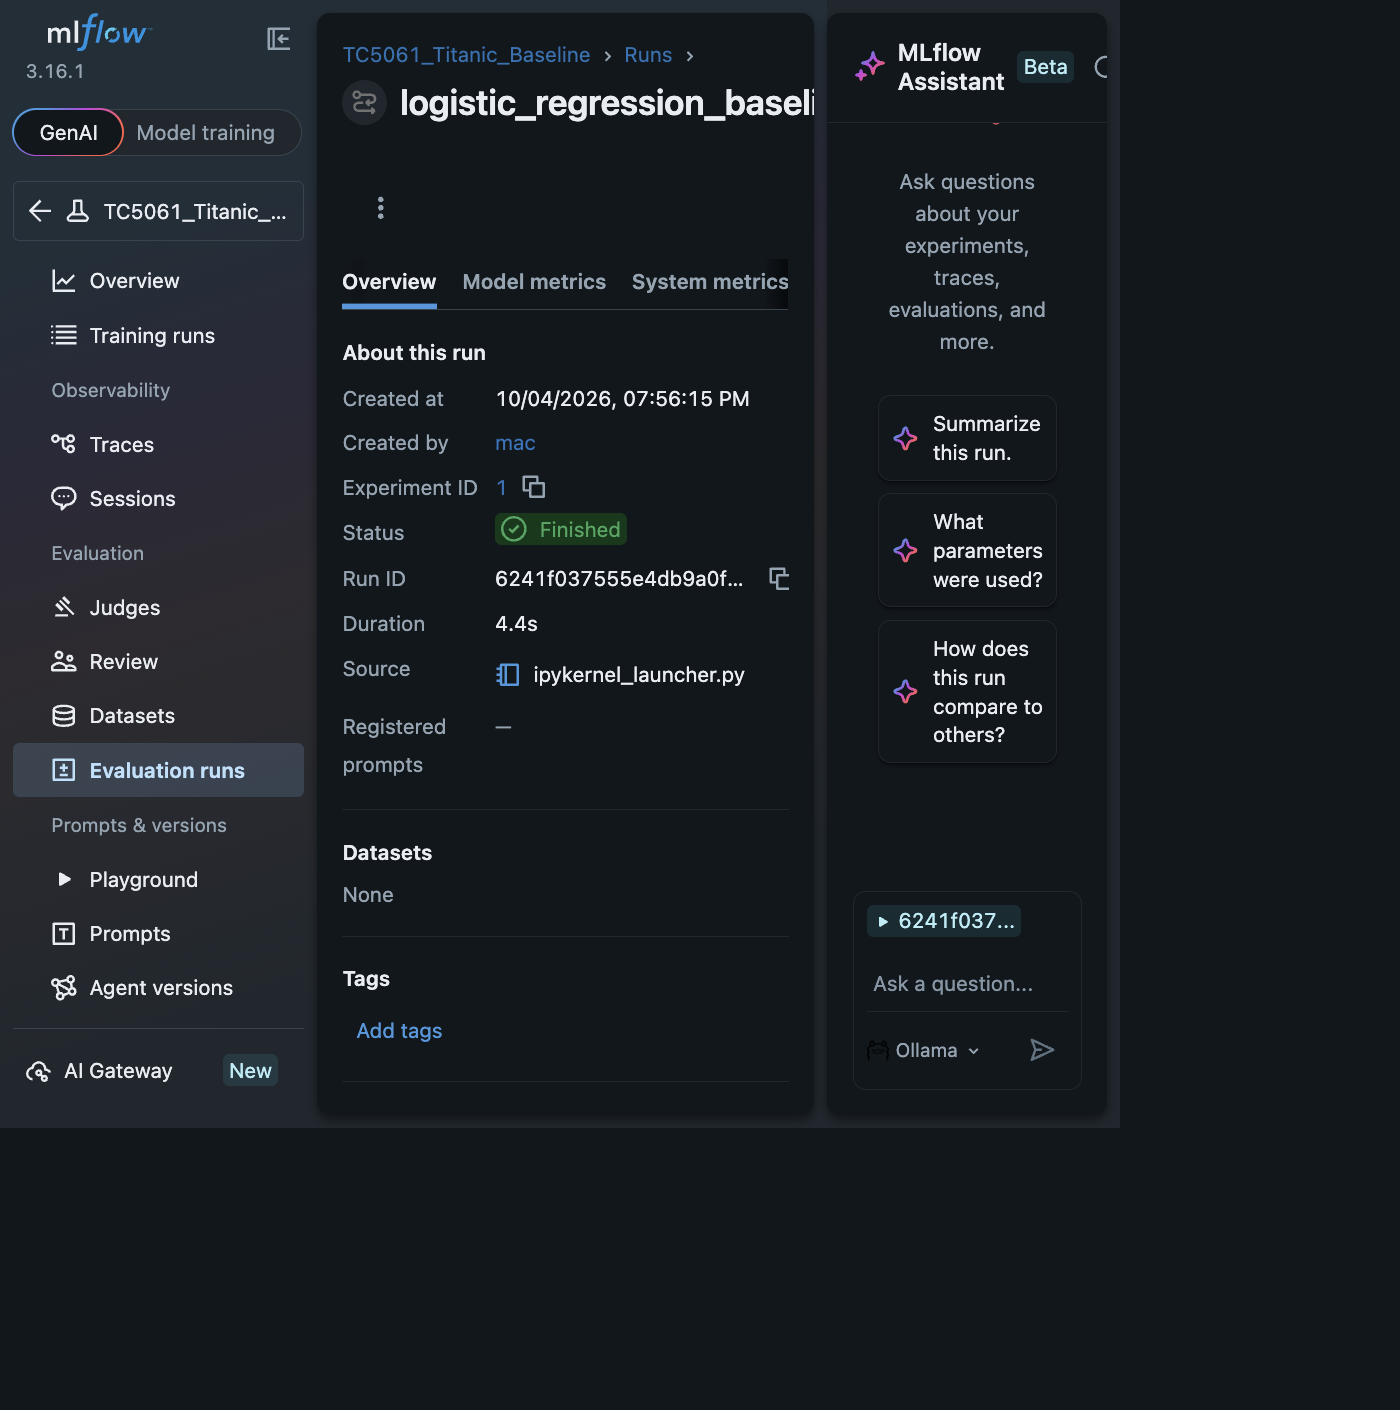

In [11]:
from IPython.display import Image, display

display(Image(filename='mlflow_evidence.png'))